# JALEBI quick-start notebook

**J**WST **A**nalysis of **L**ine **E**mission with **B**ayesian **I**nference: simultaneous LTE slab fitting of the molecular
emission in JWST/MIRI-MRS spectra of protoplanetary disks.

In this notebook you will

1. compute LTE slab models (no data needed),
2. load a real MIRI spectrum (FZ Tau, bundled) and estimate its continuum,
3. let JALEBI detect which molecules are present,
4. fit a synthetic spectrum whose answers are known, and
5. sample the posterior with `emcee` and look at the parameter degeneracies.

Runs on a laptop in about 5 minutes. Use the kernel **Python (JALEBI)** if you installed it with `python install.py`.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml

import jalebi
from jalebi.model import Component, build_model
from jalebi.synthetic import band_pixels
from jalebi.data import load_spectrum
from jalebi.config import ProjectConfig
from jalebi.pipeline import prepare, run_pipeline, run_mcmc_stage
from jalebi.detect import detect_molecules
from jalebi.examples import example_path
from jalebi import plots

CONFIGS = Path("..") / "configs"          # the example configs next to this notebook
print("jalebi", jalebi.__version__)

jalebi 0.9.0


## 1. A single LTE slab

A slab has a column density $N$, a temperature $T$ and an emitting area $\pi R^2$. The intensity is
$I_\nu = B_\nu(T)\,(1-e^{-\tau_\nu})$, and the observed flux is $F_\nu = (\pi R^2/d^2)\, I_\nu$ convolved with the MIRI line-spread
function and integrated over each pixel. The README derives every equation.

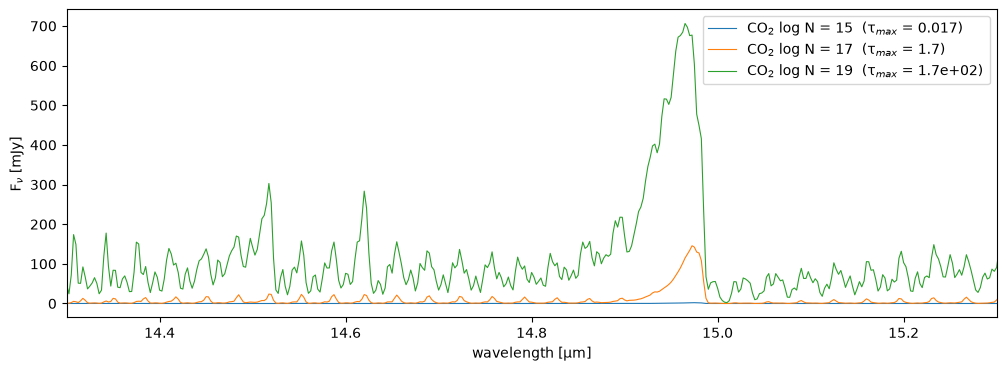

In [2]:
wave = band_pixels("3B")                      # MIRI-MRS channel 3B pixels
fig, ax = plt.subplots(figsize=(12, 4))
for logN in (15, 17, 19):
    m = build_model([Component("CO2", "CO2", logN=logN, T=500, logR=-0.5)], wave, distance_pc=140)
    ax.plot(wave, 1e3 * m.evaluate(), lw=0.8, label=f"CO$_2$ log N = {logN}  (τ$_{{max}}$ = {m.tau_flags()['CO2']:.2g})")
ax.set_xlim(14.3, 15.3); ax.set_xlabel("wavelength [µm]"); ax.set_ylabel("F$_ν$ [mJy]"); ax.legend();

## 2. Real data: FZ Tau

The twelve MIRI-MRS sub-band spectra (`Level3_ch*_x1d.fits`) of FZ Tau (JWST GO 1549) are bundled. Anywhere a path is expected
you can write `example:FZ_Tau`. For your own targets, give the folder that holds the x1d files.

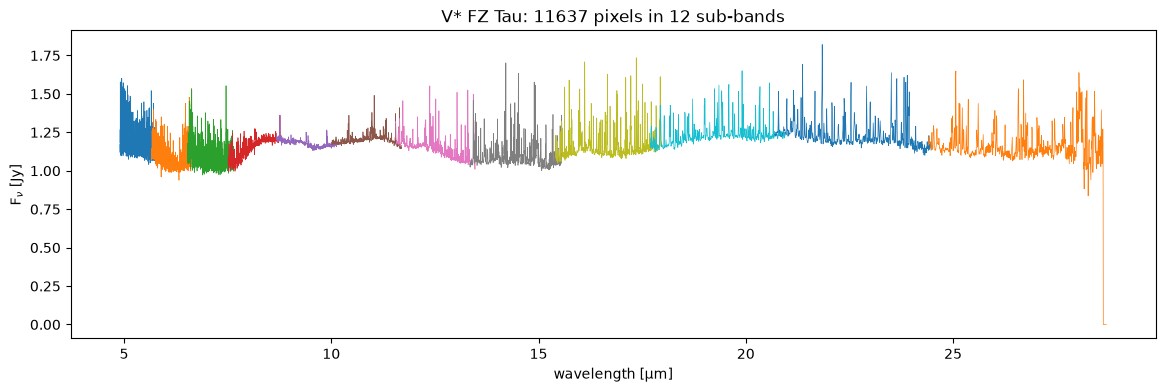

In [3]:
fz = load_spectrum("example:FZ_Tau", distance_pc=130).to_rest_frame(20.0)
fig, ax = plt.subplots(figsize=(14, 4))
for b in fz.bands:
    i = fz.band_slice(b)
    ax.plot(fz.wave[i], fz.flux[i], lw=0.5)
ax.set_xlabel("wavelength [µm]"); ax.set_ylabel("F$_ν$ [Jy]"); ax.set_title(f"{fz.name}: {len(fz.wave)} pixels in {len(fz.bands)} sub-bands");

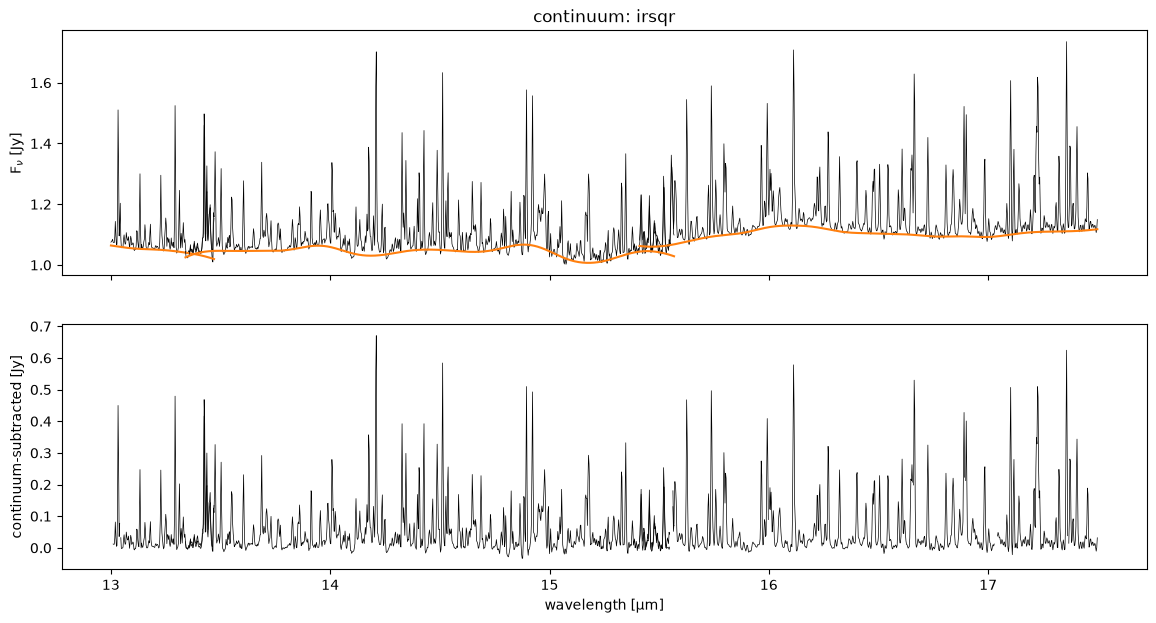

In [4]:
cfg = ProjectConfig.load(CONFIGS / "FZ_Tau_quick.yaml")        # continuum method, masks, components, windows
spec = prepare(cfg)                                              # rest frame, spikes, continuum, masks, noise
sel = (spec.wave > 13.0) & (spec.wave < 17.5)
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for b in spec.bands:
    i = spec.band_slice(b); i = i[sel[i]]
    if len(i):
        ax[0].plot(spec.wave[i], spec.flux[i], "k", lw=0.5); ax[0].plot(spec.wave[i], spec.continuum[i], "tab:orange")
        ax[1].plot(spec.wave[i], np.where(spec.mask[i], spec.line_flux[i], np.nan), "k", lw=0.5)
ax[0].set_ylabel("F$_ν$ [Jy]"); ax[1].set_ylabel("continuum-subtracted [Jy]"); ax[1].set_xlabel("wavelength [µm]")
ax[0].set_title(f"continuum: {cfg.continuum.method}");

## 3. Which molecules are there?

`detect_molecules` fits LTE templates of every molecule with a line list simultaneously (non-negative least squares) and
keeps a molecule when removing it costs more than the BIC penalty (ΔBIC > 10).

In [5]:
det = detect_molecules(spec, threshold=10)
det.table[["candidate", "T", "logR", "delta_BIC", "detected", "windows"]].round(1)

,candidate,T,logR,delta_BIC,detected,windows
0,CO,1500.0,-0.6,1797.7,True,4.90-5.35
1,H2O_hot,850.0,-0.8,1180.1,True,"5.00-8.00, 12.00-17.50"
2,H2O_warm,400.0,-0.1,125.5,True,"5.00-8.00, 12.00-17.50"
3,CO2,600.0,-0.5,76.5,True,14.60-16.40
4,H2O_cold,170.0,0.6,30.0,True,17.50-27.50
5,C2H2,600.0,-0.6,10.7,True,13.50-14.20
6,HCN,600.0,-0.3,-1.8,False,13.80-14.30
7,C2H6,300.0,0.8,-2.3,False,11.80-12.40
8,C2H4,300.0,0.3,-8.2,False,10.30-10.70
9,NH3,600.0,-0.8,-12.3,False,9.50-11.50


## 4. Fit a synthetic spectrum with known answers

The bundled synthetic spectrum was made from H$_2$O + CO$_2$/$^{13}$CO$_2$ + C$_2$H$_2$ + HCN slabs with the parameters in
`synthetic_truth.yaml`. Here we run the grid and optimiser stages only (about a minute).

In [6]:
scfg = ProjectConfig.load(CONFIGS / "synthetic.yaml")
scfg.fit.optimise.workers = 2
run = run_pipeline(scfg, stages=["grid", "optimise"], save=False)
truth = yaml.safe_load(open(example_path("synthetic/synthetic_truth.yaml")))
P, _ = run.problem.params_from_theta(run.theta)
for c in truth["components"]:
    if not c.get("tie_to"):
        print(f"{c['name']:5s} T {c['T']:5.0f} -> {P[c['name']]['T']:5.0f} K   log N {c['logN']:.2f} -> {P[c['name']]['logN']:.2f}"
              f"   log R {c['logR']:.2f} -> {P[c['name']]['logR']:.2f}")

[12:38:27] synthetic disk: 1136 pixels in 1 windows, 12 free parameters, 47239 fine-grid points
[12:38:27] grid: H2O on [(13.6, 16.3)]
[12:38:28]   best log N=18.00 T=600 K log R=-0.37 chi2_red=2.50
[12:38:28] grid: CO2 on [(13.6, 16.3)]
[12:38:29]   best log N=18.00 T=400 K log R=-0.73 chi2_red=2.14
[12:38:29] grid: C2H2 on [(13.6, 16.3)]
[12:38:29]   best log N=16.50 T=600 K log R=-0.76 chi2_red=1.65
[12:38:29] grid: HCN on [(13.6, 16.3)]
[12:38:30]   best log N=15.00 T=700 K log R=-0.06 chi2_red=1.55 (at grid edge)
[12:38:30] optimise: de, maxiter=40 generations x popsize=8 x 8 params = up to 2560 model evaluations, workers=2
[12:38:30]   generation 1/40: best -2lnP = 1691.5  (1s elapsed, ~29s left)
[12:38:32]   generation 5/40: best -2lnP = 1691.5  (2s elapsed, ~14s left)
[12:38:33]   generation 10/40: best -2lnP = 1634.2  (3s elapsed, ~9s left)
[12:38:34]   generation 15/40: best -2lnP = 1582.0  (4s elapsed, ~7s left)
[12:38:35]   generation 20/40: best -2lnP = 1554.9  (5s elapsed

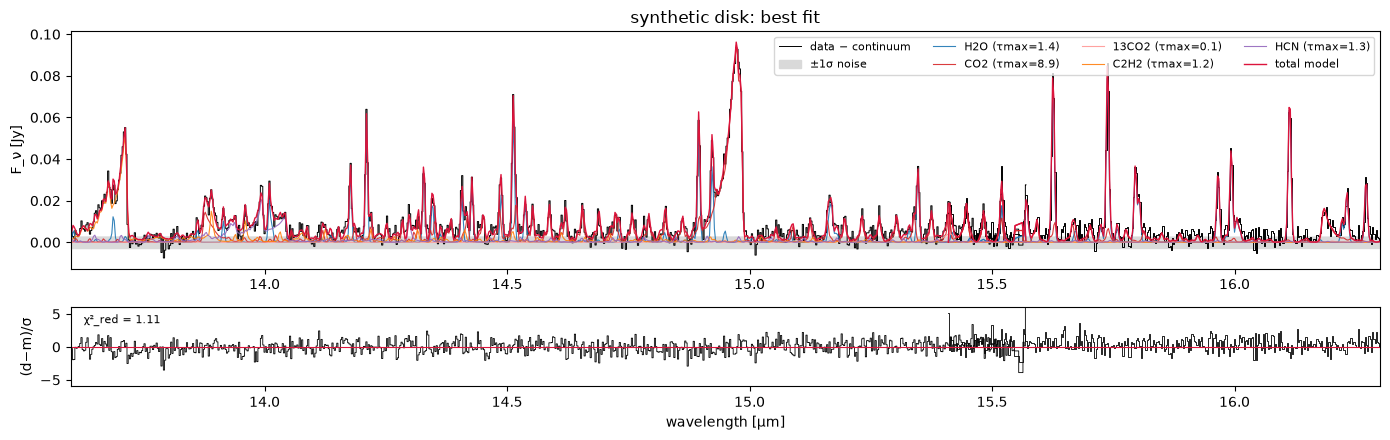

In [7]:
fig = plots.plot_fit(run.problem, run.theta, title="synthetic disk: best fit")

## 5. Posterior with emcee

A short chain for illustration; a real fit needs at least ~50 autocorrelation times and $\hat R < 1.05$. The correlation
matrix shows the degeneracies: $N$–$R$ for optically thin components (only $N\cdot A$ is constrained), and $T$–$N$ within a
component.

[12:39:10] mcmc: nwalkers=32, nsteps=200, processes=2 (6,400 likelihood calls; checkpoint off)
[12:39:17]   step 50/200: acceptance 0.38, <lnP> 5017.7, tau~6 (9 tau so far), 7s elapsed, ~22s left
[12:39:25]   step 100/200: acceptance 0.39, <lnP> 5017.8, tau~11 (9 tau so far), 15s elapsed, ~15s left
[12:39:31]   step 150/200: acceptance 0.38, <lnP> 5018.6, tau~17 (9 tau so far), 21s elapsed, ~7s left
[12:39:37]   step 200/200: acceptance 0.38, <lnP> 5018.5, tau~22 (9 tau so far), 27s elapsed, ~0s left
[12:39:37]   done: acceptance=0.38 max tau=22 steps/tau=9 (need >= 50 tau) max Rhat=1.898 burn-in 43 (27s)
acceptance 0.38, 9 autocorrelation times (short demo chain)


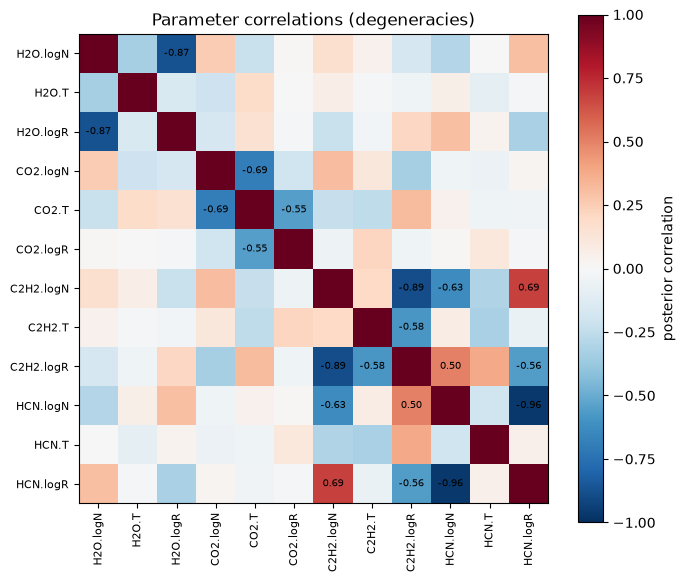

In [8]:
scfg.fit.mcmc.nsteps = 200; scfg.fit.mcmc.nwalkers = 32; scfg.fit.mcmc.processes = 2
run_mcmc_stage(run)
d = run.mcmc.diagnostics()
print(f"acceptance {d['acceptance']:.2f}, {d['steps_over_tau']:.0f} autocorrelation times (short demo chain)")
fig = plots.plot_correlation(run.mcmc)

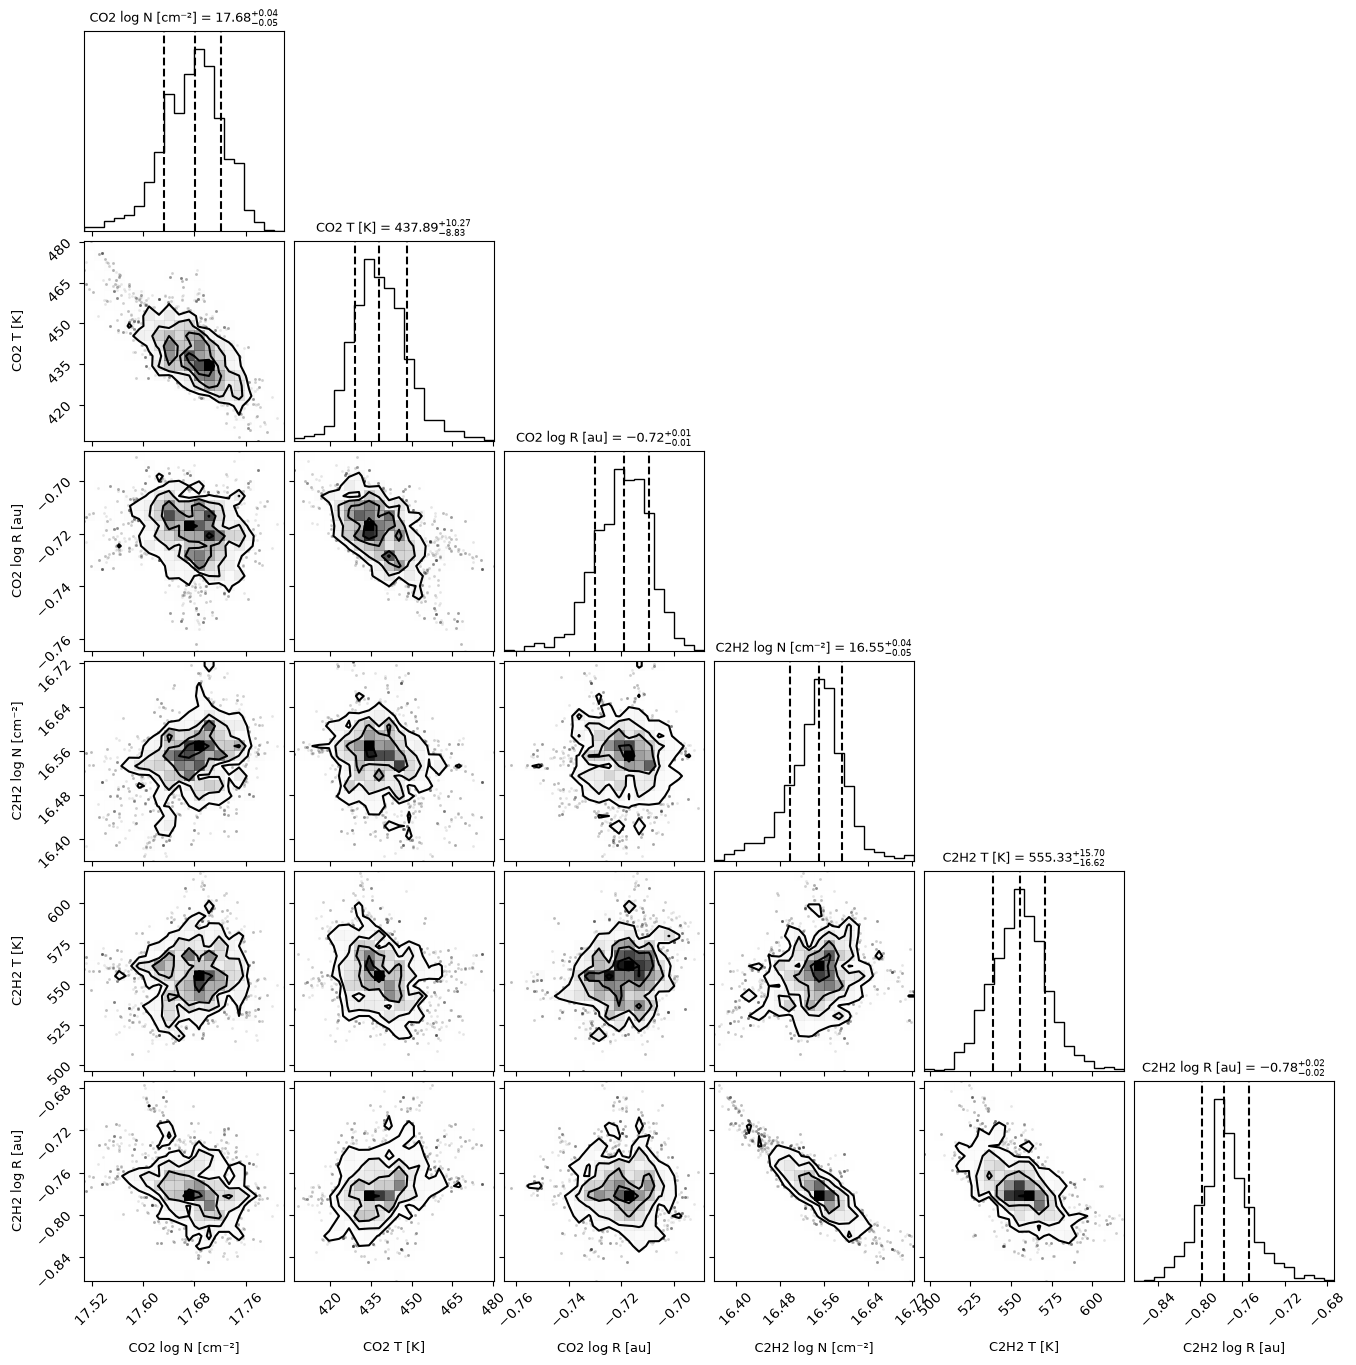

In [9]:
fig = plots.plot_corner(run.mcmc, comps=["CO2", "C2H2"])

## Next steps

* the web app: `jalebi serve --show` (live sliders, click the continuum anchors, background fits, corner plots),
* start your own target from a config: `jalebi init my_disk.yaml --example fz_tau`, then `jalebi fit my_disk.yaml`,
* many disks: `jalebi batch config.yaml targets.csv --workers 16`,
* the physics, the priors and every option are in the README.